# CSC-321: Data Mining and Machine Learning
# Jordin Palmeri

## Assignment 4: Logistic Regression

### Part 1: Prediction

Everything so far has been a regression task - predicting a numeric value. We've also talked about classification in class, so let's implement our first basic binary classifier. This is the same idea as linear regression, but instead of predicting a continous numeric value, we're going to predict one of two binary classes, using logistic regression.

The general outline for logistic regression is the same as for multivariate linear regression. We're going to need a function to make predictions, and a function to learn coefficients.

(a) The formula for making a prediction, predY, for logistic regression is:

predY = 1.0 / 1.0 + e^-(b0 + b1 * x1 + ... + bN * xN)

Where b0 is the intercept or bias, bN is the coefficient for the input variable xN, and e is the base of the natural logarithms, or Euler's number. We can use the python math library which has an implementation of e called math.exp(val): https://docs.python.org/3/library/math.html. The val here in math.exp(val) is the calculation of -(b0 + b1 * x1 + ... + bN * xN); note the negative.

The formula given above is an implementation of a sigmoid function (a commonly used, s-shaped function that can take any input value and produce a number between 0 and 1).

We will assume there can be multiple input features (x1, x2 etc) not just a single value, and that each input feature will have a corresponding coefficient (b1, b2 etc).

Write your predict function, that will take a single instance, and a list of coefficients, and return a prediction. In the list of coefficients, assume coefficient[0] corresponds to b0. This will be very similar to your predict function from last week.

    

In [ ]:
# Write your predict function here
import math

def predict(row, coefficients):
  y = coefficients[0]
  for i in range(len(row)):
    y += coefficients[i + 1] * row[i]
  return 1.0 / (1.0 + math.exp(-y))



We can test your predict function on the contrived dataset below. It includes TWO input features (we shall call x1 and x2) and a class feature (y) for each instance. The class is either 0 or 1.

(b) Graph the instances in this data, x1 (on the x axis) against x2 (on the y axis), using different colored points for the two classes. You may choose the colors. Use axes ranges of 0-10 on the x, and -1 to 6 on the y. There are TEN instances in this data - so make sure there are 10 points plotted.

(c) Call your predict function on each instance in the contrived data set, using the coefficients given below. Get the predicted class from your function, and print (for each instance), the expected class, the predicted value AND the predicted class. In order to get the predicted class from the value predicted, we need to do rounding. There is a round() function that can help you. If it works correctly, you should predict the correct class of each instance in the dataset.

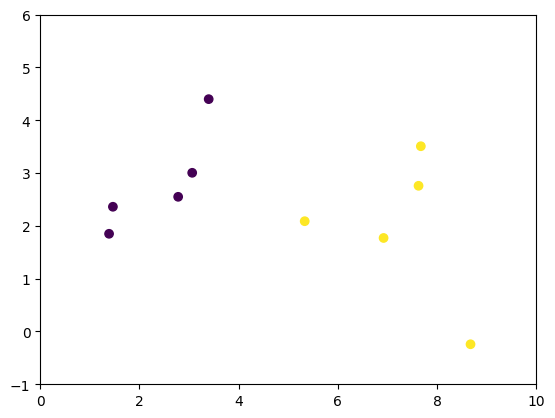

Expected=0, Predicted Value=0.299, Predicted Class=0
Expected=0, Predicted Value=0.146, Predicted Class=0
Expected=0, Predicted Value=0.085, Predicted Class=0
Expected=0, Predicted Value=0.220, Predicted Class=0
Expected=0, Predicted Value=0.247, Predicted Class=0
Expected=1, Predicted Value=0.955, Predicted Class=1
Expected=1, Predicted Value=0.862, Predicted Class=1
Expected=1, Predicted Value=0.972, Predicted Class=1
Expected=1, Predicted Value=0.999, Predicted Class=1
Expected=1, Predicted Value=0.905, Predicted Class=1


In [ ]:
# Here's the contrived data set

dataset = [[2.7810836,2.550537003,0],
    [1.465489372,2.362125076,0],
    [3.396561688,4.400293529,0],
    [1.38807019,1.850220317,0],
    [3.06407232,3.005305973,0],
    [7.627531214,2.759262235,1],
    [5.332441248,2.088626775,1],
    [6.922596716,1.77106367,1],
    [8.675418651,-0.242068655,1],
    [7.673756466,3.508563011,1]]


# Do the graphing here
import matplotlib.pyplot as plt

x1 = [row[0] for row in dataset]
x2 = [row[1] for row in dataset]
y = [row[2] for row in dataset]

plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.scatter(x1, x2, c=y)
plt.show()


# Call your predict function on the data here, using the following coefficients

coef = [-0.406605464, 0.852573316, -1.104746259]

for row in dataset:
    predicted_value = predict(row[:-1], coef)
    predicted_class = round(predicted_value)
    expected_class = row[-1]
    print(f"Expected={expected_class}, Predicted Value={predicted_value:.3f}, Predicted Class={predicted_class}")

# Go through each instance of X_train, and get a predicted y value
# Print out the predicted y, and the corresponding actual y from y_train



### Part 2: Learning coefficients

(d) Above I gave you coefficients. Just as with MLR last week, we need to estimate the coefficients for a data set. To do that, we're going to use stochastic gradient descent. The algorithm is exactly the same as for multivariate linear regression except for the following two things.

b0 is computed by:

b0 = b0 + learning_rate * error * predictedY * (1.0 - predictedY)

and bN is computed by:

bN = bN + learning_rate * error * predictedY * (1.0 - predictedY) * xN

for all coefficients b1..bN

To **calculate the error**, we run the algorithm with default coefficients and perform prediction, then get the error by subtracting the **predictedY** from the **actual Y value**. This is the opposite way around to last week. I'm just keeping you on your toes (actually, I've reversed the gradient. You're welcome).

Refer back to Assignment 3 for the complete algorithm

(e) Apply your coefficient learning function to the contrived dataset given above, using the learning rate of 0.3, and 100 epochs. Print the resulting coefficients. I've shown the last 5 epochs of my code over this example, so you can check your code. YOUR OUTPUT SHOULD BE THE SAME VALUES (or possibly off by a VERY small amount). Note how I compact my output.


In [ ]:
# Write your function sgd_log(X_train, y_train, learning_rate, epochs) here

def sgd_log(X_train, y_train, learning_rate, epochs):
  coef = [0.0 for i in range(len(X_train[0]) + 1)]

  for epoch in range(epochs):
    sum_error = 0

    for i in range(len(X_train)):
      predicted = predict(X_train[i], coef)
      error = y_train[i] - predicted
      sum_error += error**2
      coef[0] = coef[0] + learning_rate * error * predicted * (1.0 - predicted)

      for j in range(len(X_train[i])):
        coef[j + 1] = coef[j + 1] + learning_rate * error * predicted * (1.0 - predicted) * X_train[i][j]
    print('>epoch=%d, lrate=%.3f, error=%.3f' % (epoch, learning_rate, sum_error))

  return coef



# Call your function using the parameters given here.
learning_rate = 0.3
epochs = 100

X_train = [row[:-1] for row in dataset]
y_train = [row[-1] for row in dataset]

coef = sgd_log(X_train, y_train, learning_rate, epochs)
print("Coefficients:", coef)

# Example output
#
#>epoch=95, lrate=0.300, error=0.023
#>epoch=96, lrate=0.300, error=0.023
#>epoch=97, lrate=0.300, error=0.023
#>epoch=98, lrate=0.300, error=0.023
#>epoch=99, lrate=0.300, error=0.022


>epoch=0, lrate=0.300, error=2.217
>epoch=1, lrate=0.300, error=1.613
>epoch=2, lrate=0.300, error=1.113
>epoch=3, lrate=0.300, error=0.827
>epoch=4, lrate=0.300, error=0.623
>epoch=5, lrate=0.300, error=0.494
>epoch=6, lrate=0.300, error=0.412
>epoch=7, lrate=0.300, error=0.354
>epoch=8, lrate=0.300, error=0.310
>epoch=9, lrate=0.300, error=0.276
>epoch=10, lrate=0.300, error=0.248
>epoch=11, lrate=0.300, error=0.224
>epoch=12, lrate=0.300, error=0.205
>epoch=13, lrate=0.300, error=0.189
>epoch=14, lrate=0.300, error=0.174
>epoch=15, lrate=0.300, error=0.162
>epoch=16, lrate=0.300, error=0.151
>epoch=17, lrate=0.300, error=0.142
>epoch=18, lrate=0.300, error=0.134
>epoch=19, lrate=0.300, error=0.126
>epoch=20, lrate=0.300, error=0.119
>epoch=21, lrate=0.300, error=0.113
>epoch=22, lrate=0.300, error=0.108
>epoch=23, lrate=0.300, error=0.103
>epoch=24, lrate=0.300, error=0.098
>epoch=25, lrate=0.300, error=0.094
>epoch=26, lrate=0.300, error=0.090
>epoch=27, lrate=0.300, error=0.087
>e

### Part 3: Classification algorithms

(f) Now you have sufficient functionality to write a function to make predictions using logistic regression. Create a function with the signature log_reg(X_train, y_train, X_test, learning_rate, epochs).

We're going to use the same dataset here for both training and testing, even though we know that might not be a great idea.

Here's the log_reg algorithm. We're going to estimate our coefficients from the training data, using the function from (d) above, and we'll print them out. We're going to create a new list, to hold our predictions. Then for each entry in the testing data, we're going to read the input value, and make a prediction, using our function from (a). For each entry in the test data, we're going to append our predicted y class to the prediction list. In order to predict the class correctly, we need to round our score, as above, before appending it. We're going to return our list of predictions.

In [ ]:
# Write your function log_reg(X_train, y_train, X_test, learning_rate, epochs) here

def log_reg(X_train, y_train, X_test, learning_rate, epochs):
  coef = sgd_log(X_train, y_train, learning_rate, epochs)
  print("Coefficients:", coef)

  predictions = []
  for row in X_test:
    predicted_value = predict(row, coef)
    predicted_class = round(predicted_value)
    predictions.append(predicted_class)

  return predictions





(g) Now we need a function for calculating accuracy. We need to keep count of how many predictions are correct. It will take a list of actual class values, and a list of predicted class values. If the actual value of an instance and the predicted value of an instance are the same, increment a counter. In the end, return the value of this counter divided by the length of the actual values list. Call this function accuracy.

(h) We also need a baseline function. Create a function called zeroRC(train, test). This function should take the training data, and find the most common value of Y in the training data. It should then return a list of predictions the same length as the test data, containing ONLY this value that was most common. It works very similarly to the zeroR function you've been using for linear regression.

(i) Apply logistic regression and zeroRC to the sample dataset. Use a learning rate of 0.3 and 100 epochs for logistic regression. Calculate accuracy for both algorithms, and print the results as a **percentage accuracy**. Give me a write up on the experiment below - which algorithm is better?

(j) See how the error rate for the SGD learned coefficients goes down? Write in the text box the error rate at iteration 100, and the error rate at iteration 10. Run the code with just 10 epochs and perform analysis of the resulting classification accuracy over the test data. Does the classification accuracy of the overall classifier change? Add something in the write up about this.


In [ ]:
# Do the code here

def accuracy(actual, predicted):
  correct = 0
  for i in range(len(actual)):
    if actual[i] == predicted[i]:
      correct += 1
  return correct / len(actual) * 100

def zeroRC(train, test):
  output_values = [row[-1] for row in train]
  prediction = max(set(output_values), key=output_values.count)
  predictions = [prediction for i in range(len(test))]
  return predictions

X_train = [row[:-1] for row in dataset]
y_train = [row[-1] for row in dataset]
X_test = X_train

lr = 0.3
epochs = 10

log_reg_predictions = log_reg(X_train, y_train, X_test, lr, epochs)
zeroR_predictions = zeroRC(dataset, X_test)

log_reg_accuracy = accuracy(y_train, log_reg_predictions)
zeroR_accuracy = accuracy(y_train, zeroR_predictions)

print(f"Logistic Regression Accuracy: {log_reg_accuracy:.2f}%")
print(f"ZeroR Accuracy: {zeroR_accuracy:.2f}%")

>epoch=0, lrate=0.300, error=2.217
>epoch=1, lrate=0.300, error=1.613
>epoch=2, lrate=0.300, error=1.113
>epoch=3, lrate=0.300, error=0.827
>epoch=4, lrate=0.300, error=0.623
>epoch=5, lrate=0.300, error=0.494
>epoch=6, lrate=0.300, error=0.412
>epoch=7, lrate=0.300, error=0.354
>epoch=8, lrate=0.300, error=0.310
>epoch=9, lrate=0.300, error=0.276
Coefficients: [-0.4066054639903037, 0.8525733163581036, -1.1047462590413233]
Logistic Regression Accuracy: 100.00%
ZeroR Accuracy: 50.00%


We can see that the logistic regression model is outperforming the ZeroR model:
  - Logistic Regression: Accuracy = 100%
  - ZeroR: Accuracy = 50%

Code Running at 100 Epochs:
  - Iteration 10 Error = 0.276
  - Iteration 100 Error = 0.022

Code Running at 10 Epochs:
  - Iteration 10 Error = 0.276

While only doing 10 epochs, the accuracy of logistic regression is still 100%. Which means that our algorithm was good enough to learn this small dataset in only 10 epochs. It is important to note that the error is quite a bit higher for 10 epochs as opposed to 100 epochs, which means that our model is not able to fully converge.


### Part 4: Introduction to scikit-learn

One of the most popular open-source python machine learning libraries is scikit-learn. You can find out more in general at: https://scikit-learn.org/stable/index.html

This time, I'm only doing the bare minimum. I'll load the relevant models from scikit-learn, but it's up to you to train and test them, and report the scores appropriately. I want you to use scikits SGD Classifier (working as a logistic regression), but there's also a separate built-in logistic regressor so you'll use both. I also want you to generate a confusion matrix.

Do the following:
- Train the SGD Classifier, using the fit method (note: I'm using the 'log_loss' loss parameter, which means it will behave as logistic regression. There are other options).
  - Print out information about the model, including the coefficients, the intercept and the number of iterations it took to train
  - Compare these coefficients to the ones you learned. They WILL be different
  - Use the model to predict values for X_test
- Evaluate performance using the imported accuracy_metric
- Train and test the standard logistic regression model from sklearn
- Train and test the dummy classifier (zeroR) using the most frequent class as a baseline
- Print out the ACCURACY for all three
- Plot the confusion matrix for BOTH the SGD-based logistic regressor, AND for zeroR. Include a comparison between these two outputs in your write up. You'll have to do reading of the documentation linked below. PLEASE do it the way this page describes, AND NOT any other way.
- Add a text box AFTER the results commenting on which model(s) are better, and comparing the coefficients your code learned, to those of the SGD Classifier you used here.

Important links:
- [SGD Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier)
- [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
- [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
- [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)




=== SGDClassifier ===
Coefficients: [[ 14.56151431 -24.99131208]]
Intercept: [-4.99000978]
Number of iterations: 7
Accuracy: 100.0 %

=== LogisticRegression ===
Coefficients: [[ 1.18386528 -0.35813566]]
Intercept: [-4.55177778]
Accuracy: 100.0 %

=== DummyClassifier (ZeroR) ===
Predictions: [0 0 0 0 0 0 0 0 0 0]
Accuracy: 50.0 %


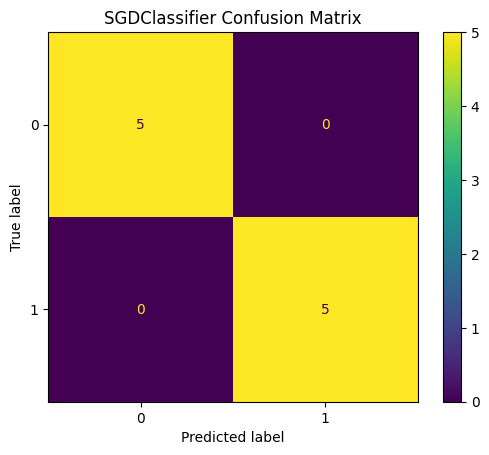

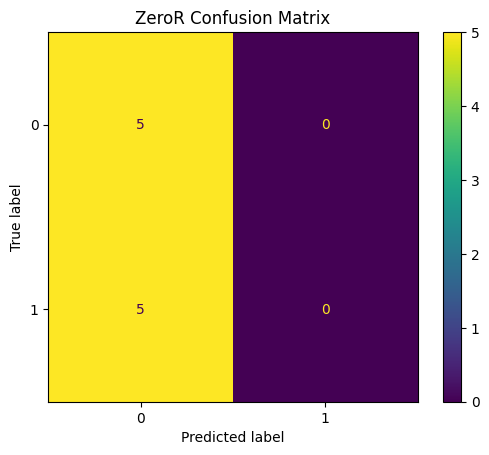

In [ ]:
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


# Use this dataset for all examples

dataset = [[2.7810836,2.550537003,0],
    [1.465489372,2.362125076,0],
    [3.396561688,4.400293529,0],
    [1.38807019,1.850220317,0],
    [3.06407232,3.005305973,0],
    [7.627531214,2.759262235,1],
    [5.332441248,2.088626775,1],
    [6.922596716,1.77106367,1],
    [8.675418651,-0.242068655,1],
    [7.673756466,3.508563011,1]]

# **************************************************************************
# CREATE YOUR X_train,y_train, X_Test,y_test datasets here

X_train = [row[:-1] for row in dataset]
y_train = [row[-1] for row in dataset]
X_test = X_train
y_test = y_train

# **************************************************************************


# ======================================
# SGD
# ======================================
sgd_clf = SGDClassifier(loss='log_loss',max_iter=50)
sgd_clf.fit(X_train, y_train)

print("=== SGDClassifier ===")
print("Coefficients:", sgd_clf.coef_)
print("Intercept:", sgd_clf.intercept_)
print("Number of iterations:", sgd_clf.n_iter_)

sgd_pred = sgd_clf.predict(X_test)
sgd_acc = accuracy_score(y_test, sgd_pred)
print("Accuracy:", sgd_acc * 100.0, "%")


# ======================================
# Logistic Regression
# ======================================
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

print("\n=== LogisticRegression ===")
print("Coefficients:", lr_clf.coef_)
print("Intercept:", lr_clf.intercept_)

lr_pred = lr_clf.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print("Accuracy:", lr_acc * 100.0, "%")


# ======================================
# ZeroR
# ======================================
zr_clf = DummyClassifier(strategy="most_frequent")
zr_clf.fit(X_train, y_train)

zr_pred = zr_clf.predict(X_test)
zr_acc = accuracy_score(y_test, zr_pred)
print("\n=== DummyClassifier (ZeroR) ===")
print("Predictions:", zr_pred)
print("Accuracy:", zr_acc * 100.0, "%")


# ======================================
# SGD Confusion Matrix
# ======================================
cm_sgd = confusion_matrix(y_test, sgd_pred, labels=sgd_clf.classes_)
disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd,
                                  display_labels=sgd_clf.classes_)
disp_sgd.plot()
plt.title("SGDClassifier Confusion Matrix")
plt.show()


# ======================================
# ZeroR Confussion Matrix
# ======================================
cm_zr = confusion_matrix(y_test, zr_pred, labels=zr_clf.classes_)
disp_zr = ConfusionMatrixDisplay(confusion_matrix=cm_zr,
                                 display_labels=zr_clf.classes_)
disp_zr.plot()
plt.title("ZeroR Confusion Matrix")
plt.show()

Confusion Matrices:

 - SGD-based logistic regression: perfect diagonal (all points classified correctly).

 - ZeroR: all predictions are the most frequent class (0), misclassifying all 1s.

Comparison and Accuracy:

 - Logistic regression models (hand-coded and scikit-learn) achieve 100% accuracy.

 - ZeroR achieves only 50% accuracy, showing it cannot separate the classes.

Coefficients:

 - Hand-coded coefficients: [-0.407, 0.853, -1.105]

 - SGDClassifier coefficients: [14.562, -24.991], intercept: [-4.990]

 - Coefficients likely differ due to initialization and optimization, but the predicted classes are the same on this dataset.